<a href="https://colab.research.google.com/github/Rukshana-S/ecommerce-product-recommendation-knn/blob/main/Ecommerce_Product_Recommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

PROJECT_PATH = "/content/drive/MyDrive/ecommerce-product-recommendation-knn"

folders = [
    "data",
    "models",
    "outputs",
    "outputs/charts"
]

for folder in folders:
    os.makedirs(os.path.join(PROJECT_PATH, folder), exist_ok=True)

print("Project folders created.")

Project folders created.


In [4]:
import os

# List the contents of the data folder
print(os.listdir(os.path.join(PROJECT_PATH, "data")))


['ecommerce_mock_dataset.csv']


In [6]:
import pandas as pd

# DATA_PATH is already defined in the kernel context
# DATA_PATH = os.path.join(PROJECT_PATH,"data","ecommerce_mock_dataset.csv")

df = pd.read_csv(DATA_PATH)

display(df.head())

,Customer_ID,Product_ID,Product_Category,Purchase_History,Rating,Browsing_Behaviour,Transaction_Date
0,C001,P801,Accessories,Yes,4.5,Purchased,2025-01-27
1,C001,P102,Electronics,Yes,3.6,Wishlist,2025-01-27
2,C001,P105,Electronics,Yes,3.5,Frequently Viewed,2025-01-27
3,C001,P503,Home,Yes,4.6,Wishlist,2025-06-16
4,C001,P701,Books,Yes,4.2,Frequently Viewed,2025-06-16


In [7]:
df = df.drop_duplicates()

df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

df["Browsing_Behaviour"] = df["Browsing_Behaviour"].str.strip()

df["Product_Category"] = df["Product_Category"].str.title()

df = df.dropna()

clean_path = os.path.join(PROJECT_PATH,"data","ecommerce_cleaned.csv")

df.to_csv(clean_path,index=False)

print(df.shape)

(250, 7)


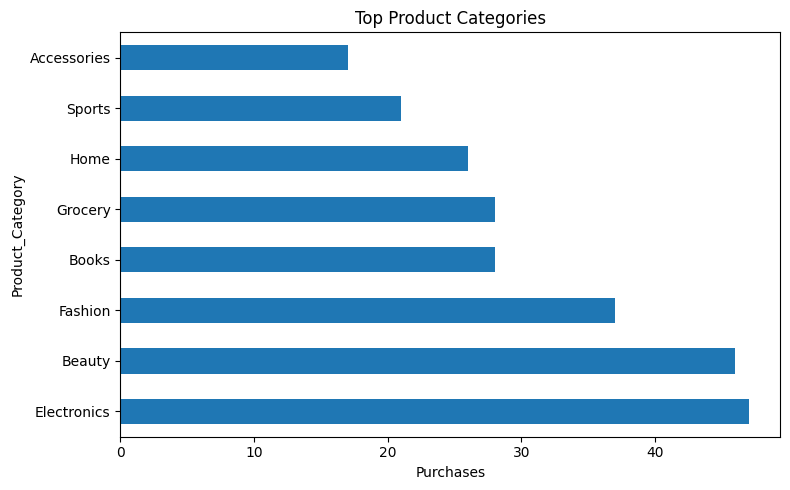

In [8]:
import matplotlib.pyplot as plt

category_counts = df["Product_Category"].value_counts()

plt.figure(figsize=(8,5))
category_counts.plot(kind="barh")
plt.title("Top Product Categories")
plt.xlabel("Purchases")

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_PATH,"outputs/charts/top_categories.png"))

plt.show()

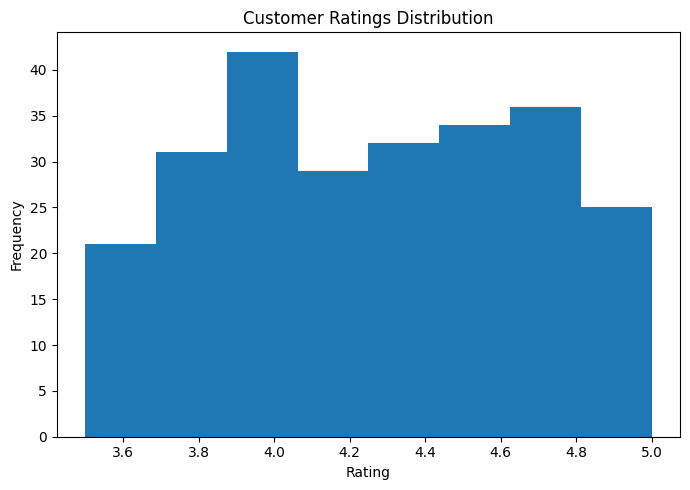

In [9]:
plt.figure(figsize=(7,5))

plt.hist(df["Rating"], bins=8)

plt.title("Customer Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_PATH,"outputs/charts/rating_distribution.png"))

plt.show()

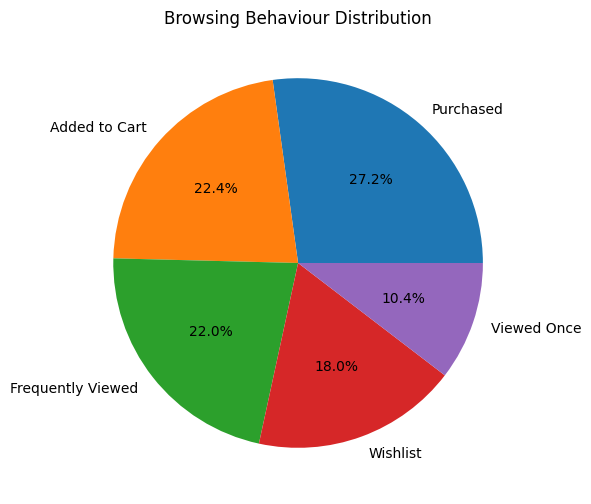

In [10]:
behaviour = df["Browsing_Behaviour"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    behaviour,
    labels=behaviour.index,
    autopct="%1.1f%%"
)

plt.title("Browsing Behaviour Distribution")

plt.savefig(os.path.join(PROJECT_PATH,"outputs/charts/browsing_behaviour.png"))

plt.show()